<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/M5_2a_GloVe_Geometry.ipynb)

# The geometry of words: GloVe

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Before we build any models: what does a word *look like* to a computer? **GloVe** gives each of 400,000 words a vector, learned from 6 billion words of Wikipedia and news - and those vectors have **geometry**. Similar words sit close together, and the *direction* from *man* to *woman* is the same as the direction from *king* to *queen*. This is the idea behind every embedding in this module (and inside every large language model).

In [1]:
# seed everything: same numbers on my screen and yours
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
keras.utils.set_random_seed(5509)

In [2]:
# Download GloVe from Stanford (the original source).
# Heads up: glove.6B.zip is ~822MB, so this cell takes a few minutes.
!wget -q https://nlp.stanford.edu/data/glove.6B.zip
# Un-zip -> glove.6B.50d.txt, 100d, 200d and 300d into /content/
!unzip -q glove.6B.zip

In [3]:
# read the 100-number version: one line per word - the word, then its 100 numbers
glove_dir = '/content/'
embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.100d.txt'), encoding='utf-8')
for line in f:
    values = line.split()
    embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')
f.close()
print('Found %s word vectors.' % len(embeddings_index))
print('king =', embeddings_index['king'][0:8].round(2), '... (100 numbers)')

Found 400000 word vectors.
king = [-0.32 -0.88  0.22  0.25  0.23  0.74 -0.38 -0.35] ... (100 numbers)


In [4]:
# stack all 400,000 vectors into one matrix and scale each to length 1, so a dot product = cosine similarity
glove_words = list(embeddings_index.keys())
glove_matrix = np.array(list(embeddings_index.values()))
glove_unit = glove_matrix / np.linalg.norm(glove_matrix, axis=1, keepdims=True)
row_of = {}
for k in range(len(glove_words)):
    row_of[glove_words[k]] = k

def nearest(vector, n=6, skip=()):
    """The n words whose vectors point the same way as `vector`."""
    sims = glove_unit @ (vector / np.linalg.norm(vector))
    order = np.argsort(-sims)
    out = []
    for k in order:
        if glove_words[k] not in skip:
            out.append((glove_words[k], round(float(sims[k]), 2)))
        if len(out) == n:
            break
    return out

# neighbours: words used in similar ways
for w in ['king', 'storm', 'hail', 'movie', 'excellent']:
    print(f'{w:10s} ->', nearest(embeddings_index[w], skip=(w,)))

king       -> [('prince', 0.77), ('queen', 0.75), ('son', 0.7), ('brother', 0.7), ('monarch', 0.7), ('throne', 0.69)]
storm      -> [('hurricane', 0.88), ('storms', 0.82), ('winds', 0.81), ('typhoon', 0.76), ('cyclone', 0.74), ('tropical', 0.72)]
hail       -> [('storms', 0.55), ('rain', 0.53), ('pelted', 0.53), ('tornadoes', 0.52), ('winds', 0.52), ('sleet', 0.51)]
movie      -> [('film', 0.91), ('movies', 0.9), ('films', 0.87), ('hollywood', 0.82), ('comedy', 0.81), ('drama', 0.77)]
excellent  -> [('good', 0.79), ('quality', 0.76), ('terrific', 0.74), ('superb', 0.74), ('best', 0.73), ('impressive', 0.72)]


In [5]:
# the classic: king - man + woman = ?
def analogy(a, b, c, vectors=embeddings_index):
    """a is to b as c is to ...?   (b - a + c)"""
    return nearest(vectors[b] - vectors[a] + vectors[c], n=3, skip=(a, b, c))

print('man : king   :: woman  :', analogy('man', 'king', 'woman'))
print('france : paris :: italy :', analogy('france', 'paris', 'italy'))
print('walk : walking :: swim :', analogy('walk', 'walking', 'swim'))
print('big : bigger :: small  :', analogy('big', 'bigger', 'small'))

man : king   :: woman  : [('queen', 0.78), ('monarch', 0.69), ('throne', 0.68)]
france : paris :: italy : [('rome', 0.81), ('milan', 0.73), ('naples', 0.71)]
walk : walking :: swim : [('swimming', 0.81), ('surfing', 0.66), ('swam', 0.65)]
big : bigger :: small  : [('larger', 0.88), ('smaller', 0.86), ('large', 0.79)]


### See it: every word is a strip of colors
Draw each word's 100 numbers as a strip of colors (red = big positive, blue = big negative). Similar words share **bands** of color - and *king - man + woman* looks almost exactly like *queen*.

In [ ]:
strip_words = ['king', 'queen', 'prince', 'princess', 'man', 'woman', 'boy', 'girl', 'water']
rows = []
labels = []
for w in strip_words:
    rows.append(embeddings_index[w])
    labels.append(w)
mix = embeddings_index['king'] - embeddings_index['man'] + embeddings_index['woman']
rows.insert(2, mix)                          # put the arithmetic right under queen
labels.insert(2, 'king - man + woman')

plt.figure(figsize=(16, 6))
plt.imshow(np.array(rows), aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.yticks(range(len(labels)), labels, fontsize=12)
plt.xlabel('GloVe number (1-100)')
plt.colorbar(label='value')
plt.title('Every word is a strip of 100 colors')
plt.show()

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
print('similarity(king - man + woman, queen) =', round(cosine(mix, embeddings_index['queen']), 2))
print('similarity(king, queen) =', round(cosine(embeddings_index['king'], embeddings_index['queen']), 2),
      '| similarity(king, water) =', round(cosine(embeddings_index['king'], embeddings_index['water']), 2))

In [ ]:
# zoom in: the 12 numbers the ROYAL words agree on, and the 12 the PEOPLE words agree on
def stack(words):
    out = []
    for w in words:
        out.append(embeddings_index[w])
    return np.array(out)

def agree(group):
    """Big when every word in the group has the same strong value: |average| minus spread."""
    return np.abs(group.mean(axis=0)) - group.std(axis=0)

royal_dims = list(np.argsort(-agree(stack(['king', 'queen', 'prince', 'princess'])))[0:12])
people_dims = []
for d in np.argsort(-agree(stack(['man', 'woman', 'boy', 'girl']))):
    if d not in royal_dims:
        people_dims.append(d)
    if len(people_dims) == 12:
        break

plt.figure(figsize=(12, 6))
plt.imshow(np.array(rows)[:, royal_dims + people_dims], aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
plt.yticks(range(len(labels)), labels, fontsize=12)
plt.axvline(11.5, color='black', linewidth=2)
plt.xticks([5.5, 17.5], ['12 numbers the ROYAL words agree on', '12 numbers the PEOPLE words agree on'])
plt.title('Zoomed in: shared bands of color = shared meaning')
plt.show()
# royal words (and king - man + woman!) share the left block; man, woman, boy, girl share the right; water matches neither

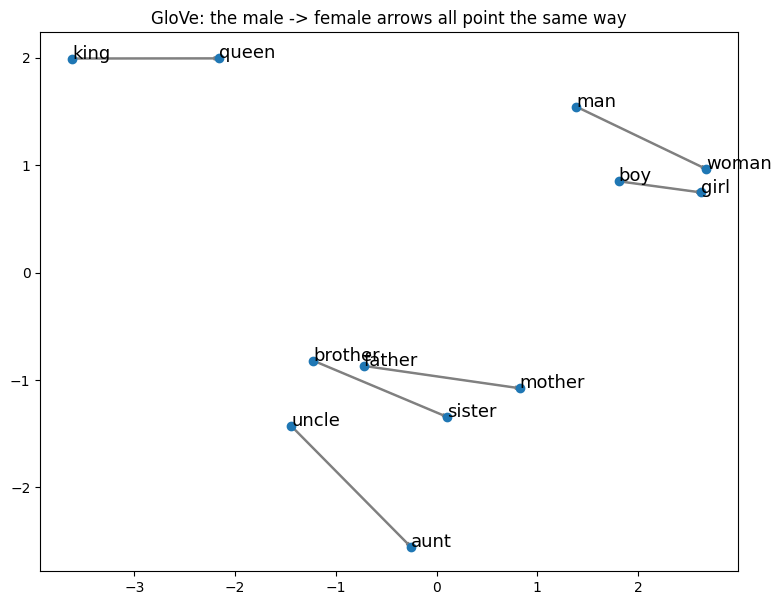

In [6]:
# the picture: squash the vectors to 2-D - the man->woman arrow runs parallel to king->queen, boy->girl, ...
from sklearn.decomposition import PCA
pairs = [('man', 'woman'), ('king', 'queen'), ('boy', 'girl'), ('brother', 'sister'), ('uncle', 'aunt'), ('father', 'mother')]
pair_words = []
for a, b in pairs:
    pair_words.append(a)
    pair_words.append(b)
vectors = []
for w in pair_words:
    vectors.append(embeddings_index[w])
xy = PCA(n_components=2).fit_transform(np.array(vectors))

plt.figure(figsize=(9, 7))
for k in range(0, len(pair_words), 2):
    plt.arrow(xy[k, 0], xy[k, 1], xy[k + 1, 0] - xy[k, 0], xy[k + 1, 1] - xy[k, 1],
              color='grey', width=0.01, length_includes_head=True)
for k in range(len(pair_words)):
    plt.scatter(xy[k, 0], xy[k, 1], color='tab:blue')
    plt.annotate(pair_words[k], (xy[k, 0], xy[k, 1]), fontsize=13)
plt.title('GloVe: the male -> female arrows all point the same way')
plt.show()

In [7]:
# does size matter? the same analogy with 50, 100 and 300 numbers per word
# (the 100,000 most common words of each file - plenty for this, and fast)
for dim in [50, 100, 300]:
    small = {}
    f = open(os.path.join(glove_dir, f'glove.6B.{dim}d.txt'), encoding='utf-8')
    for k, line in enumerate(f):
        if k == 100000:
            break
        values = line.split()
        small[values[0]] = np.asarray(values[1:], dtype='float32')
    f.close()
    words_d = list(small.keys())
    unit_d = np.array(list(small.values()))
    unit_d = unit_d / np.linalg.norm(unit_d, axis=1, keepdims=True)
    target = small['king'] - small['man'] + small['woman']
    sims = unit_d @ (target / np.linalg.norm(target))
    order = np.argsort(-sims)
    top = []
    for k in order:
        if words_d[k] not in ('king', 'man', 'woman'):
            top.append(words_d[k])
        if len(top) == 3:
            break
    queen_sim = float(unit_d[words_d.index('queen')] @ (target / np.linalg.norm(target)))
    print(f'{dim:3d} numbers per word: king - man + woman -> {top}   (similarity to queen {queen_sim:.2f})')

 50 numbers per word: king - man + woman -> ['queen', 'daughter', 'prince']   (similarity to queen 0.86)


100 numbers per word: king - man + woman -> ['queen', 'monarch', 'throne']   (similarity to queen 0.78)


300 numbers per word: king - man + woman -> ['queen', 'monarch', 'throne']   (similarity to queen 0.69)


### Two real movie reviews, as GloVe sees them
Every word becomes a column of 100 numbers. Words GloVe has never seen stay all zeros - a real-world gotcha.

In [8]:
# two IMDB reviews (the last 20 words of each), turned back into words
from keras.datasets import imdb
from keras.utils import pad_sequences
maxlen = 20
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)
x_train = pad_sequences(x_train, maxlen=maxlen)
word_index = imdb.get_word_index()
index_word = {0: '<pad>', 1: '<start>', 2: '<unk>'}
for word, rank in word_index.items():
    index_word[rank + 3] = word
label_name = {0: 'negative', 1: 'positive'}
peek_words = []
for k in [0, 1]:
    words = []
    for number in x_train[k]:
        words.append(index_word.get(number, '?'))
    peek_words.append(words)
    print('review', k, '(' + label_name[y_train[k]] + '):', ' '.join(words))

review 0 (positive): story was so lovely because it was true and was someone's life after all that was shared with us all
review 1 (negative): on the disaster that was the 80's and have a good old laugh at how bad everything was back then


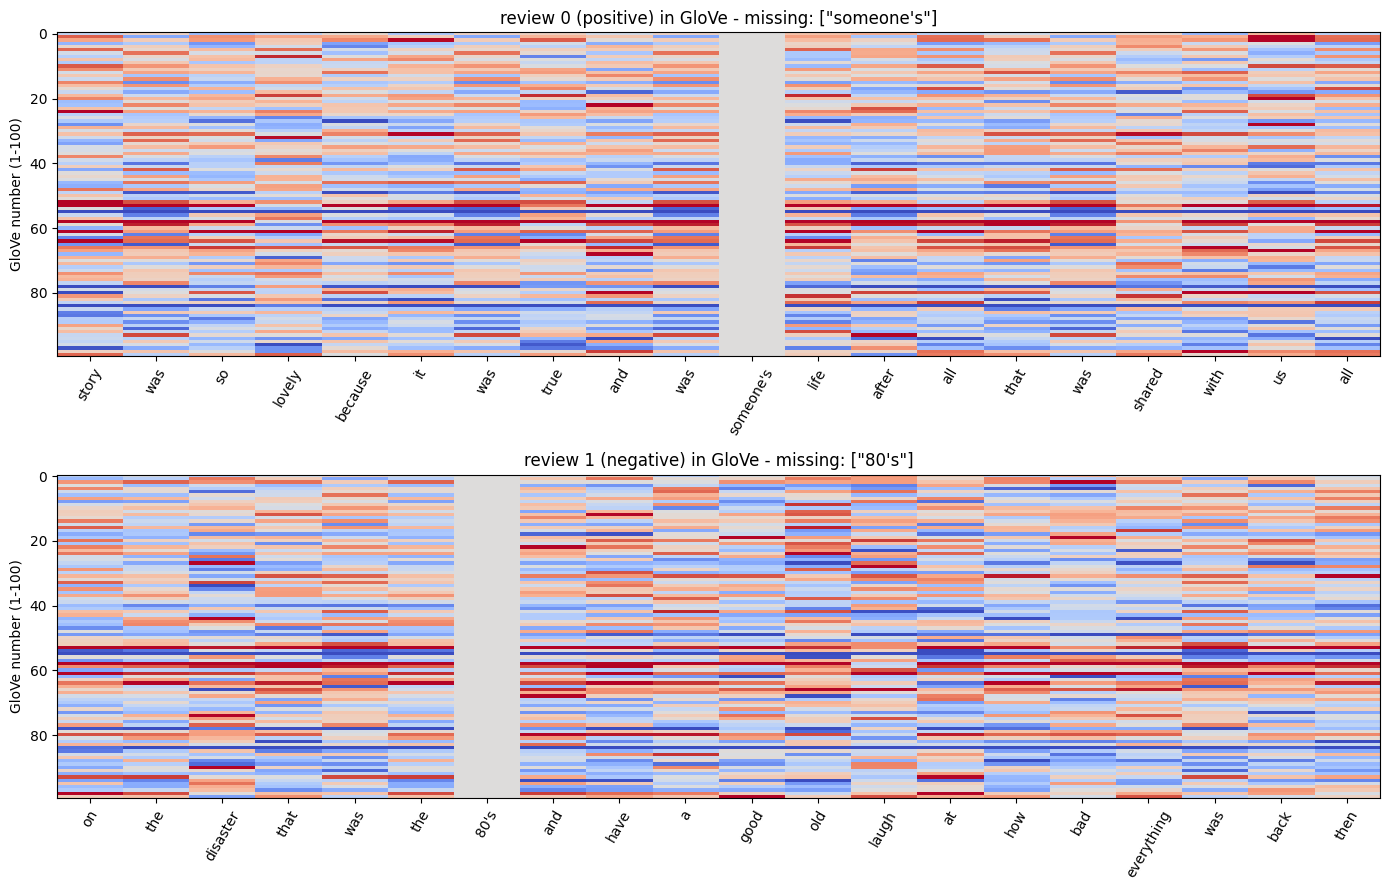

In [9]:
# the same two reviews from the top of the notebook, as GloVe sees them: 20 words x 100 numbers
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for k in [0, 1]:
    grid = np.zeros((100, len(peek_words[k])))
    missing = []
    for j in range(len(peek_words[k])):
        w = peek_words[k][j]
        if w in embeddings_index:
            grid[:, j] = embeddings_index[w]
        else:
            missing.append(w)          # not in GloVe -> stays all zeros
    axes[k].imshow(grid, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    axes[k].set_xticks(range(len(peek_words[k])))
    axes[k].set_xticklabels(peek_words[k], rotation=60)
    axes[k].set_ylabel('GloVe number (1-100)')
    axes[k].set_title('review ' + str(k) + ' (' + label_name[y_train[k]] + ') in GloVe - missing: ' + str(missing))
plt.tight_layout()
plt.show()